# DCT Laboratory — Volume II, Chapter 3
## Convex Enterprise Optimization
**Seed `26203`** · Companion to the chapter and AXIOM Module **AXIOM-03 (Vol. II)**

Convexity's three dividends, computed: a **Hessian certificate** and the unique
global optimum it guarantees, **strong duality** on a capacity-constrained cost
problem — duality gap zero, and the multiplier revealed as the **shadow price**
of capacity — and **Jensen's inequality** as the blends proposition made
numerical. Mirrored in `DCT_V2_Ch03_Lab.xlsx`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi']=110

import numpy as np
SEED = 26203
# --- Panel 1: certificate & global optimum ---
# f(x,y) = (x-3)^2 + 2(y-2)^2 + x*y ; Hessian [[2,1],[1,4]]
HESS = np.array([[2.0,1.0],[1.0,4.0]])
def f2(x,y): return (x-3)**2 + 2*(y-2)**2 + x*y
# grad = 0: 2x + y = 6 ; x + 4y = 8
X_U, Y_U = 16/7, 10/7

# --- Panel 2: duality & the shadow price ---
# min (u-4)^2 s.t. u <= CAP ; dual g(lam) = 2*lam - lam^2/4 (CAP=2)
CAP = 2.0
def primal_star(cap): return (cap-4.0)**2 if cap < 4 else 0.0
def dual_g(lam): return 2*lam - lam**2/4
LAM_GRID = np.arange(0, 8.5, 0.5)

# --- Panel 3: Jensen / blends ---
X1, X2, TH = 1.0, 3.0, 0.5
def fj(x): return x**2

def reference_values():
    lam_star = float(LAM_GRID[int(np.argmax([dual_g(l) for l in LAM_GRID]))])
    fd_shadow = (primal_star(CAP+0.1)-primal_star(CAP))/0.1
    blend = TH*X1+(1-TH)*X2
    return {
        "hess_det": round(float(np.linalg.det(HESS)),4),
        "hess_eig_min": round(float(min(np.linalg.eigvals(HESS))),4),
        "x_uncon": round(X_U,4), "y_uncon": round(Y_U,4),
        "f_uncon": round(f2(X_U,Y_U),4),
        "primal_star": round(primal_star(CAP),4),
        "lambda_star": lam_star,
        "dual_max": round(float(max(dual_g(l) for l in LAM_GRID)),4),
        "duality_gap": round(float(primal_star(CAP)-max(dual_g(l) for l in LAM_GRID)),4),
        "fd_shadow": round(float(fd_shadow),4),
        "jensen_lhs": round(fj(blend),4), "jensen_rhs": round(TH*fj(X1)+(1-TH)*fj(X2),4),
        "jensen_gap": round(TH*fj(X1)+(1-TH)*fj(X2)-fj(blend),4),
    }
if __name__ == "__main__":
    [print(f"{k:14s} {v}") for k,v in reference_values().items()]

hess_det       7.0
hess_eig_min   1.5858
x_uncon        2.2857
y_uncon        1.4286
f_uncon        4.4286
primal_star    4.0
lambda_star    4.0
dual_max       4.0
duality_gap    0.0
fd_shadow      -3.9
jensen_lhs     4.0
jensen_rhs     5.0
jensen_gap     1.0


## Panel 1 — The certificate, then the guarantee
$f(x,y) = (x-3)^2 + 2(y-2)^2 + xy$. The Hessian is constant:
$\begin{pmatrix}2&1\\1&4\end{pmatrix}$, determinant 7, minimum eigenvalue
1.586 > 0 — **strongly convex**, certified in two numbers. The dividend
(Strong Convexity: Existence, Uniqueness, and Quadratic Growth, Prop.): the
optimum exists, is unique, and gradient = 0 finds it — $(16/7, 10/7)$, value
4.4286. Local Optima of Convex Problems Are Global (Prop.): no second basin to
fear.

Hessian det = 7.0000   eig_min = 1.5858  (>0: strongly convex)
unconstrained optimum: x = 2.2857, y = 1.4286, f = 4.4286


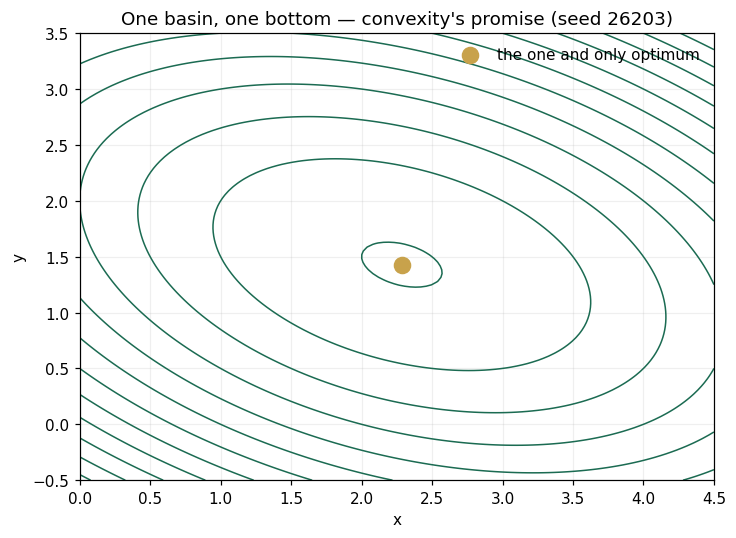

In [2]:
print(f"Hessian det = {np.linalg.det(HESS):.4f}   eig_min = {min(np.linalg.eigvals(HESS)):.4f}  (>0: strongly convex)")
print(f"unconstrained optimum: x = {X_U:.4f}, y = {Y_U:.4f}, f = {f2(X_U,Y_U):.4f}")
xs = np.linspace(0,4.5,120); ys = np.linspace(-0.5,3.5,120)
X, Y = np.meshgrid(xs, ys)
fig, ax = plt.subplots(figsize=(6.8,5.0))
cs = ax.contour(X, Y, f2(X,Y), levels=14, colors="#1B6B52", linewidths=1)
ax.scatter([X_U],[Y_U], c="#C8A24B", s=110, zorder=5, label="the one and only optimum")
ax.set(xlabel="x", ylabel="y", title="One basin, one bottom — convexity's promise (seed 26203)")
ax.legend(frameon=False); ax.grid(alpha=.2); plt.tight_layout(); plt.show()

## Panel 2 — Strong duality, and the price of a wall
Minimize $(u-4)^2$ subject to capacity $u \le 2$. Primal optimum: $p^* = 4$ at
the wall. The dual function $g(\lambda) = 2\lambda - \lambda^2/4$ peaks at
$\lambda^* = 4$ with $d^* = 4$: **duality gap zero** (Strong Duality Theorem —
convexity plus a strictly feasible point). And $\lambda^*$ is not bookkeeping:
relax the capacity and the optimal cost falls at rate $\approx 4$ per unit —
the multiplier IS the shadow price of the wall.

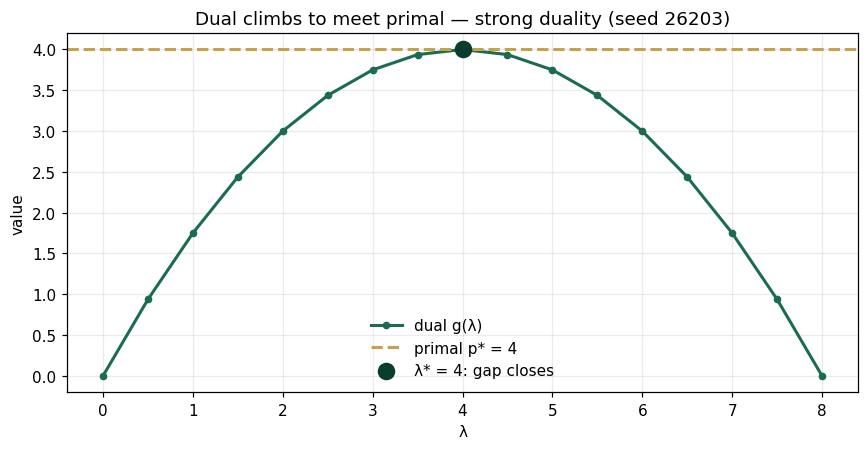

duality gap: 0.0000
shadow-price check (fd, h=0.1): dp*/dcap ≈ -3.9000  vs  −λ* = −4


In [3]:
fig, ax = plt.subplots(figsize=(8.0,4.2))
ax.plot(LAM_GRID, [dual_g(l) for l in LAM_GRID], "o-", c="#1B6B52", lw=2, ms=4, label="dual g(λ)")
ax.axhline(primal_star(CAP), c="#C8A24B", lw=2, ls="--", label=f"primal p* = {primal_star(CAP):.0f}")
ax.scatter([4],[dual_g(4)], c="#0B3D2E", s=110, zorder=5, label="λ* = 4: gap closes")
ax.set(xlabel="λ", ylabel="value", title="Dual climbs to meet primal — strong duality (seed 26203)")
ax.legend(frameon=False); ax.grid(alpha=.25); plt.tight_layout(); plt.show()
print(f"duality gap: {primal_star(CAP)-max(dual_g(l) for l in LAM_GRID):.4f}")
print(f"shadow-price check (fd, h=0.1): dp*/dcap ≈ {(primal_star(CAP+0.1)-primal_star(CAP))/0.1:.4f}  vs  −λ* = −4")

## Panel 3 — Jensen: blends are safe, and averages flatter costs
Two feasible plans $x_1 = 1$, $x_2 = 3$; convex cost $f(x) = x^2$. The 50/50
blend costs $f(2) = 4$; the average of the costs is 5. **Jensen's gap: 1.0** —
blending convex costs never surprises upward (Convex Combinations of Feasible
Enterprise Plans Remain Feasible, Prop., with the cost bound riding along).
The enterprise reading: diversified plans are both feasible and cheaper than
their components' average suggests — when, and only when, the cost is convex.

In [4]:
blend = TH*X1+(1-TH)*X2
print(f"f(blend) = f({blend:.1f}) = {fj(blend):.4f}")
print(f"blend of f = {TH:.1f}·f({X1:.0f}) + {1-TH:.1f}·f({X2:.0f}) = {TH*fj(X1)+(1-TH)*fj(X2):.4f}")
print(f"Jensen gap (rhs − lhs): {TH*fj(X1)+(1-TH)*fj(X2)-fj(blend):.4f}  (≥ 0 always, for convex f)")

f(blend) = f(2.0) = 4.0000
blend of f = 0.5·f(1) + 0.5·f(3) = 5.0000
Jensen gap (rhs − lhs): 1.0000  (≥ 0 always, for convex f)


## Validation — agrees with `DCT_V2_Ch03_Lab.xlsx`

In [5]:
ref = reference_values()
expected = {"hess_det":7.0,"hess_eig_min":1.5858,"x_uncon":2.2857,"y_uncon":1.4286,"f_uncon":4.4286,
 "primal_star":4.0,"lambda_star":4.0,"dual_max":4.0,"duality_gap":0.0,"fd_shadow":-3.9,
 "jensen_lhs":4.0,"jensen_rhs":5.0,"jensen_gap":1.0}
for k,v in expected.items():
    assert abs(ref[k]-v)<5e-4, f"MISMATCH {k}"
    print(f"PASS  {k:14s} {ref[k]}")
print("\nAll checkpoints agree — seed 26203.")

PASS  hess_det       7.0
PASS  hess_eig_min   1.5858
PASS  x_uncon        2.2857
PASS  y_uncon        1.4286
PASS  f_uncon        4.4286
PASS  primal_star    4.0
PASS  lambda_star    4.0
PASS  dual_max       4.0
PASS  duality_gap    0.0
PASS  fd_shadow      -3.9
PASS  jensen_lhs     4.0
PASS  jensen_rhs     5.0
PASS  jensen_gap     1.0

All checkpoints agree — seed 26203.


**Next**: Exercises 3.9–3.12 (Part C) tighten the capacity and watch λ* move; AXIOM-03's duality dashboard prices every wall live. Solutions: IM Vol. II, Ch. 3.